<a href="https://colab.research.google.com/github/gorodnichenko16-cell/-/blob/main/%D0%94%D0%97_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip -q install torch torchvision kagglehub tqdm pandas matplotlib seaborn

In [24]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [25]:
import kagglehub

path = kagglehub.dataset_download("alexattia/the-simpsons-characters-dataset")
print("Kaggle path:", path)
print(os.listdir(path))

data_dir = os.path.join(path, "simpsons_dataset")
print("Data dir:", data_dir)
print("Sample class dirs:", os.listdir(data_dir)[:10])

100%|██████████| 1.08G/1.08G [00:15<00:00, 74.4MB/s]

Extracting files...


Kaggle path: /root/.cache/kagglehub/datasets/alexattia/the-simpsons-characters-dataset/versions/4
['characters_illustration.png', 'weights.best.hdf5', 'annotation.txt', 'number_pic_char.csv', 'simpsons_dataset', 'kaggle_simpson_testset']
Data dir: /root/.cache/kagglehub/datasets/alexattia/the-simpsons-characters-dataset/versions/4/simpsons_dataset
Sample class dirs: ['maggie_simpson', 'ralph_wiggum', 'barney_gumble', 'homer_simpson', 'bart_simpson', 'gil', 'lionel_hutz', 'moe_szyslak', 'marge_simpson', 'rainier_wolfcastle']


Уменьшаем данные для скорости

In [26]:
good_train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

bad_train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(70),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.9, contrast=0.9,
                           saturation=0.9, hue=0.3),
    transforms.RandomAffine(degrees=60, translate=(0.3, 0.3),
                            scale=(0.6, 1.4)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

subset

In [27]:
def make_loaders(train_tfms, val_tfms, batch_size=32, subset_size=3000, val_ratio=0.2):
    full_ds = datasets.ImageFolder(root=data_dir, transform=train_tfms)
    classes = full_ds.classes
    num_classes = len(classes)
    print("Classes:", num_classes, classes[:5])

    # subset для ускорения
    indices = list(range(min(subset_size, len(full_ds))))
    subset = Subset(full_ds, indices)

    n_val = int(len(subset) * val_ratio)
    n_train = len(subset) - n_val
    train_ds, val_ds = random_split(
        subset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(seed)
    )

    # валид. датасет с val_tfms
    val_ds.dataset = datasets.ImageFolder(root=data_dir, transform=val_tfms)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, classes, num_classes

Модель MobileNetV2 с transfer learning

In [28]:
def make_mobilenet(num_classes, freeze_backbone=True):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    # заменяем head под количество классов
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

Общие функции обучения + LR scheduler

In [29]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

def fit_model(model, train_loader, val_loader, epochs, optimizer, scheduler=None):
    criterion = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        if scheduler is not None:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch}: train={tr_loss:.4f}, val={val_loss:.4f}, acc={val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, hist, best_acc

Эксперимент 1 — StepLR

In [31]:
train_loader_good, val_loader_good, classes, num_classes = make_loaders(
    good_train_tfms, val_tfms, batch_size=32, subset_size=3000, val_ratio=0.2
)

model_step = make_mobilenet(num_classes, freeze_backbone=True).to(device)
optimizer_step = optim.Adam(filter(lambda p: p.requires_grad, model_step.parameters()), lr=1e-3)
scheduler_step = StepLR(optimizer_step, step_size=2, gamma=0.5)

model_step, hist_step, acc_step = fit_model(
    model_step, train_loader_good, val_loader_good,
    epochs=4, optimizer=optimizer_step, scheduler=scheduler_step
)

Classes: 43 ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


Epoch 1: train=1.1458, val=0.7587, acc=0.8033


Epoch 2: train=0.6009, val=0.5533, acc=0.8717


Epoch 3: train=0.4961, val=0.4854, acc=0.8750


Epoch 4: train=0.4488, val=0.4564, acc=0.8750


Эксперимент 2 — ReduceLROnPlateau

In [33]:
train_loader_good2, val_loader_good2, classes, num_classes = make_loaders(
    good_train_tfms, val_tfms, batch_size=32, subset_size=3000, val_ratio=0.2
)

model_red = make_mobilenet(num_classes, freeze_backbone=True).to(device)
optimizer_red = optim.Adam(filter(lambda p: p.requires_grad, model_red.parameters()), lr=1e-3)
scheduler_red = ReduceLROnPlateau(optimizer_red, mode="min", factor=0.5, patience=1)

model_red, hist_red, acc_red = fit_model(
    model_red, train_loader_good2, val_loader_good2,
    epochs=4, optimizer=optimizer_red, scheduler=scheduler_red
)

Classes: 43 ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


Epoch 1: train=1.1605, val=0.7629, acc=0.8183


Epoch 2: train=0.6091, val=0.5557, acc=0.8733


Epoch 3: train=0.4813, val=0.4664, acc=0.8783


Epoch 4: train=0.3948, val=0.3912, acc=0.8933


Плохие аугментации (падение accuracy > 10%)

In [34]:
train_loader_bad, val_loader_bad, classes, num_classes = make_loaders(
    bad_train_tfms, val_tfms, batch_size=32, subset_size=3000, val_ratio=0.2
)

model_bad = make_mobilenet(num_classes, freeze_backbone=True).to(device)
optimizer_bad = optim.Adam(filter(lambda p: p.requires_grad, model_bad.parameters()), lr=1e-3)

model_bad, hist_bad, acc_bad = fit_model(
    model_bad, train_loader_bad, val_loader_bad,
    epochs=4, optimizer=optimizer_bad, scheduler=None
)

Classes: 43 ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


Epoch 1: train=1.3887, val=1.1713, acc=0.5433


Epoch 2: train=1.0720, val=1.0565, acc=0.6200


Epoch 3: train=1.0094, val=0.9948, acc=0.6367


Epoch 4: train=0.9599, val=0.9367, acc=0.6950


 Fine-tuning (дообучение всей сети)

In [35]:
train_loader_ft, val_loader_ft, classes, num_classes = make_loaders(
    good_train_tfms, val_tfms, batch_size=32, subset_size=3000, val_ratio=0.2
)

model_ft = make_mobilenet(num_classes, freeze_backbone=False).to(device)  # размораживаем backbone
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_ft = StepLR(optimizer_ft, step_size=2, gamma=0.5)

model_ft, hist_ft, acc_ft = fit_model(
    model_ft, train_loader_ft, val_loader_ft,
    epochs=4, optimizer=optimizer_ft, scheduler=scheduler_ft
)

Classes: 43 ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


Epoch 1: train=1.9224, val=0.3977, acc=0.9317


Epoch 2: train=0.2353, val=0.1617, acc=0.9550


Epoch 3: train=0.1309, val=0.1250, acc=0.9650


Epoch 4: train=0.1002, val=0.1013, acc=0.9700


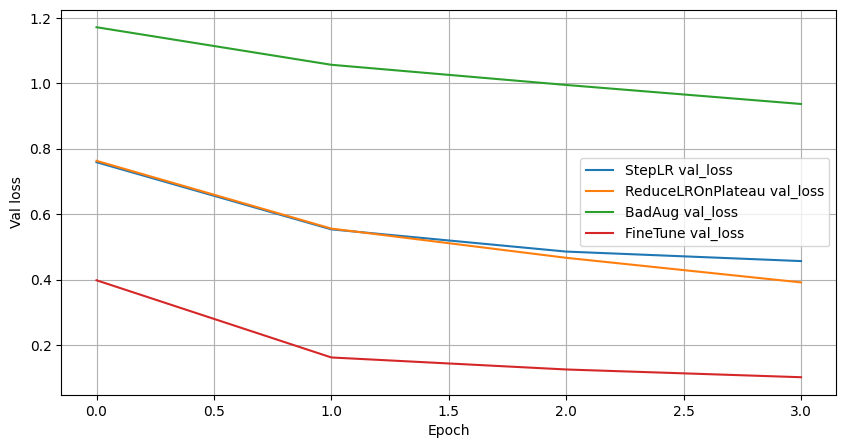

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(hist_step["val_loss"], label="StepLR val_loss")
plt.plot(hist_red["val_loss"], label="ReduceLROnPlateau val_loss")
plt.plot(hist_bad["val_loss"], label="BadAug val_loss")
plt.plot(hist_ft["val_loss"], label="FineTune val_loss")
plt.xlabel("Epoch")
plt.ylabel("Val loss")
plt.legend()
plt.grid(True)
plt.show()

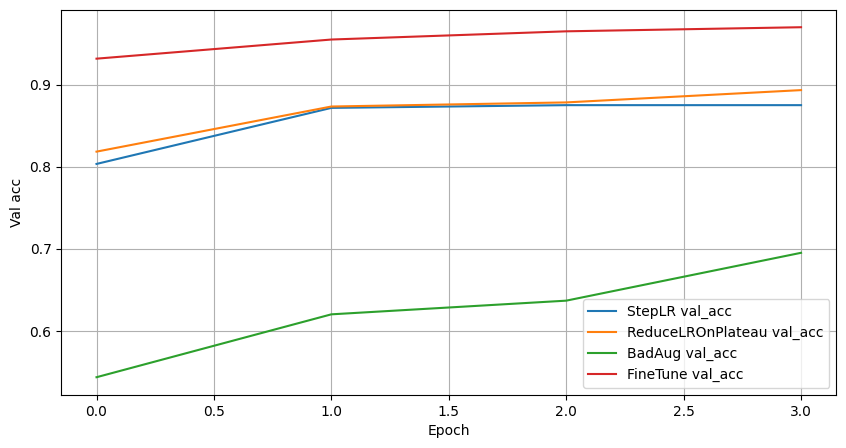

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(hist_step["val_acc"], label="StepLR val_acc")
plt.plot(hist_red["val_acc"], label="ReduceLROnPlateau val_acc")
plt.plot(hist_bad["val_acc"], label="BadAug val_acc")
plt.plot(hist_ft["val_acc"], label="FineTune val_acc")
plt.xlabel("Epoch")
plt.ylabel("Val acc")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
results = pd.DataFrame([
    {"experiment": "StepLR", "best_val_acc": acc_step},
    {"experiment": "ReduceLROnPlateau", "best_val_acc": acc_red},
    {"experiment": "BadAug", "best_val_acc": acc_bad},
    {"experiment": "FineTuning", "best_val_acc": acc_ft},
])

display(results)
results.to_csv("simpsons_transfer_results.csv", index=False)

,experiment,best_val_acc
0,StepLR,0.875000
1,ReduceLROnPlateau,0.893333
2,BadAug,0.695000
3,FineTuning,0.970000


В работе на Simpsons были проверены StepLR и ReduceLROnPlateau, а также transfer learning на MobileNetV2.

Сильные аугментации ухудшили качество валидации более чем на 10%, а fine-tuning всей сети дал результат не хуже, чем обучение только классификатора.